In [10]:
# 1. Instalamos las librerías necesarias
!pip install -q getdist emcee

import numpy as np
import pandas as pd
import scipy.integrate as integrate
import matplotlib.pyplot as plt

print("Cargando los datos...")

# 2. Cargar el "CSV" engañoso con Pandas
nombres_columnas = ['PREFIX', 'CID', 'IDSURVEY', 'zHD', 'zHEL', 'MU', 'MUERR', 'MUERR_VPEC', 'MUERR_SYS', 'PROB1A_BEAMS']

df_des = pd.read_csv('DES-Dovekie_HD.csv',
                     sep=r'\s+',
                     comment='#',
                     names=nombres_columnas
                    )

# Forzamos que las columnas sean números decimales (floats)
df_des['zHD'] = pd.to_numeric(df_des['zHD'], errors='coerce')
df_des['MU'] = pd.to_numeric(df_des['MU'], errors='coerce')

# Borramos las filas vacías
df_des = df_des.dropna(subset=['zHD', 'MU'])

z_obs = df_des['zHD'].values.astype(float)
mu_obs = df_des['MU'].values.astype(float)

# 3. Cargar la Matriz de Covarianza Inversa (.npz)
archivo_npz = np.load('STAT+SYS.npz')

nsn = int(np.squeeze(archivo_npz['nsn']))
inv_cov_cruda = archivo_npz['cov']

# --- EL DESENROLLADOR DEL TRIÁNGULO ---
# Verificamos si el tamaño coincide exactamente con el triángulo superior N*(N+1)/2
if len(inv_cov_cruda.shape) == 1 and len(inv_cov_cruda) == (nsn * (nsn + 1)) // 2:
    print(f"La matriz vino comprimida en triángulo. Reconstruyendo a {nsn}x{nsn}...")

    # 1. Creamos una matriz vacía de NxN
    inv_cov = np.zeros((nsn, nsn))

    # 2. Obtenemos las coordenadas (i, j) del triángulo superior
    i_upper, j_upper = np.triu_indices(nsn)

    # 3. Llenamos el triángulo superior con los datos crudos
    inv_cov[i_upper, j_upper] = inv_cov_cruda

    # 4. Hacemos que sea simétrica copiando lo de arriba hacia abajo
    i_lower, j_lower = np.tril_indices(nsn, -1)
    inv_cov[i_lower, j_lower] = inv_cov.T[i_lower, j_lower]

else:
    # Por si acaso la descargaste en otro formato que ya venía en 2D
    inv_cov = inv_cov_cruda.reshape((nsn, nsn))


print(f"\n¡Éxito! Se cargaron {len(z_obs)} supernovas perfectamente numéricas.")
print(f"Tamaño real de la matriz de covarianza inversa: {inv_cov.shape}")

Cargando los datos...
La matriz vino comprimida en triángulo. Reconstruyendo a 1820x1820...

¡Éxito! Se cargaron 1820 supernovas perfectamente numéricas.
Tamaño real de la matriz de covarianza inversa: (1820, 1820)


In [11]:
import emcee

# ---------------------------------------------------------
# 1. EL MODELO FÍSICO (Universo Flat Lambda-CDM)
# ---------------------------------------------------------
def E_z(z, Om):
    return np.sqrt(Om * (1 + z)**3 + (1 - Om))

def distancia_luminosidad(z_array, Om, H0):
    c = 299792.458 # km/s
    # Integramos para cada supernova en el arreglo
    ints = np.array([integrate.quad(lambda x: 1.0/E_z(x, Om), 0, zi)[0] for zi in z_array])
    return (c / H0) * (1 + z_array) * ints

def mu_teoria(z_array, Om, H0, M_offset):
    D_L = distancia_luminosidad(z_array, Om, H0)
    return 5 * np.log10(D_L * 1e5) + M_offset

# ---------------------------------------------------------
# 2. LA FUNCIÓN LIKELIHOOD (Chi-cuadrado)
# ---------------------------------------------------------
def log_likelihood(theta, z, mu_obs, inv_cov):
    Om, H0, M_offset = theta
    mu_th = mu_teoria(z, Om, H0, M_offset)
    delta_mu = mu_obs - mu_th
    # Multiplicación matricial: delta^T * C^-1 * delta
    chi2 = np.dot(delta_mu.T, np.dot(inv_cov, delta_mu))
    return -0.5 * chi2

# ---------------------------------------------------------
# 3. LOS PRIORS (¡Aquí entra SH0ES!)
# ---------------------------------------------------------
def log_prior(theta):
    Om, H0, M_offset = theta

    # Límites lógicos para que el código no colapse
    if not (0.0 < Om < 1.0 and 50.0 < H0 < 100.0 and -5.0 < M_offset < 5.0):
        return -np.inf

    # PRIOR DE SH0ES: Obligamos al H0 a estar anclado a la física local
    # (H0 = 73.04 +- 1.04 de Riess et al. 2022)
    chi2_SH0ES = ((H0 - 73.04) / 1.04)**2

    return -0.5 * chi2_SH0ES

def log_probability(theta, z, mu_obs, inv_cov):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mu_obs, inv_cov)

# ---------------------------------------------------------
# 4. EJECUTAR LA CADENA DE MARKOV (MCMC)
# ---------------------------------------------------------
n_walkers = 16
n_dim = 3  # [Omega_m, H0, M_offset]
n_steps = 1500 # Un número razonable para termalizar

# Iniciamos los caminadores cerca de los valores esperados
pos_inicial = [0.33, 73.0, 0.0] + 1e-4 * np.random.randn(n_walkers, n_dim)

sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_probability, args=(z_obs, mu_obs, inv_cov))

print(f"Iniciando MCMC de {n_steps} pasos...")
sampler.run_mcmc(pos_inicial, n_steps, progress=True)
print("¡Simulación completada!")

Iniciando MCMC de 1500 pasos...


100%|██████████| 1500/1500 [57:04<00:00,  2.28s/it]

¡Simulación completada!


Removed no burn in

--- Resultados Finales (DES + SH0ES) ---
H_0 = 73.1\pm 1.0
\Omega_m = 0.329\pm 0.015


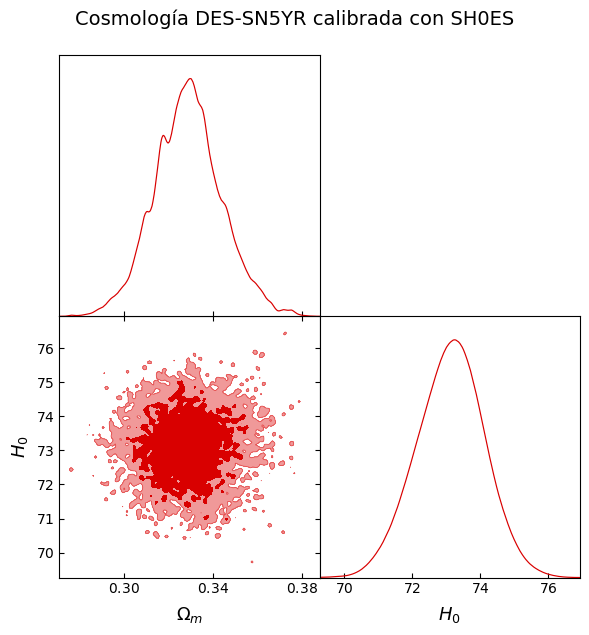


La tensión Q_DM frente a Planck es de: 5.13 sigmas


In [12]:
import getdist
from getdist import MCSamples, plots

# 1. Cortamos el primer 30% como "burn-in"
burn_in = int(0.3 * n_steps)
muestras_planas = sampler.get_chain(discard=burn_in, flat=True)

# 2. Pasamos los datos a GetDist (Columna 0 es Om, Columna 1 es H0)
muestras_para_getdist = np.column_stack((muestras_planas[:, 1], muestras_planas[:, 0]))

chain_des = MCSamples(samples=muestras_para_getdist,
                      names=['H0', 'omegam'],
                      labels=['H_0', r'\Omega_m'])

print("\n--- Resultados Finales (DES + SH0ES) ---")
print(chain_des.getInlineLatex('H0'))
print(chain_des.getInlineLatex('omegam'))

# 3. Graficar el resultado
g = plots.get_subplot_plotter(width_inch=6)
g.triangle_plot([chain_des], ['omegam', 'H0'],
                filled=True, contour_colors=["#D90000"])

plt.suptitle('Cosmología DES-SN5YR calibrada con SH0ES', fontsize=14, y=1.05)
plt.show()

# 4. Cálculo de tu métrica Q_DM frente a Planck (H0 = 67.4 +- 0.5)
H0_des_mean = chain_des.getMeans()[0]
H0_des_var = chain_des.getVars()[0]

Q_DM = ((H0_des_mean - 67.4)**2) / (H0_des_var + 0.5**2)
tension_sigmas = np.sqrt(Q_DM)

print(f"\nLa tensión Q_DM frente a Planck es de: {tension_sigmas:.2f} sigmas")

In [13]:
# Guardamos la cadena en un archivo .txt separado por espacios
# 'header' añade los nombres de las variables en la primera línea
np.savetxt('cadena_des_shoes.txt', muestras_planas,
           header='Om H0 M_offset', comments='')

print("¡Cadena guardada exitosamente como cadena_des_shoes.txt!")

# Para volver a cargarlo en el futuro:
# muestras_recuperadas = np.loadtxt('cadena_des_shoes.txt', skiprows=1)

¡Cadena guardada exitosamente como cadena_des_shoes.txt!


In [14]:
import datetime

print("Preparando los datos y el encabezado...")

# 1. Extraemos el log-posterior (post) directamente del sampler
post_plano = sampler.get_log_prob(discard=burn_in, flat=True)

# 2. Recalculamos el log-prior para cada muestra usando tu función log_prior
# (Como son muchas muestras, esto puede tardar un par de segundos)
prior_plano = np.array([log_prior(theta) for theta in muestras_planas])

# 3. Unimos las 3 columnas de parámetros con las 2 de probabilidades
# El orden será: Om, H0, M_offset, prior, post
datos_completos = np.column_stack((muestras_planas, prior_plano, post_plano))

# 4. Construimos el encabezado personalizado
# Usamos f-strings para inyectar variables reales de tu simulación
fecha_actual = datetime.datetime.now().isoformat()
muestras_totales = len(muestras_planas)

encabezado_cosmosis = f"""cosmological_parameters--omega_m	cosmological_parameters--h0	supernova_params--m	prior	post
#sampler=emcee
#n_varied=3
#timestamp={fecha_actual}
#walkers={n_walkers}
#samples={muestras_totales}
#nsteps={n_steps}
## START_OF_PARAMS_INI
## [runtime]
## sampler = emcee
## likelihood_only = T
##
## [emcee]
## walkers = {n_walkers}
## samples = {muestras_totales}
## nsteps = {n_steps}
##
## [pipeline]
## modules = consistency camb pantheon
## likelihoods = pantheon
## END_OF_PARAMS_INI
## START_OF_VALUES_INI
## [cosmological_parameters]
## omega_m = 0.0  0.33  1.0
## h0 = 50.0  73.0  100.0
##
## [supernova_params]
## m = -5.0  0.0  5.0
## END_OF_VALUES_INI
## START_OF_PRIORS_INI
## [cosmological_parameters]
## h0 = gaussian 73.04 1.04
## END_OF_PRIORS_INI"""

# 5. Guardamos el archivo
# comments='' evita que NumPy ponga un '#' extra al principio del texto
np.savetxt('cadena_des_shoes_cosmosis.txt',
           datos_completos,
           delimiter='\t',
           header=encabezado_cosmosis,
           comments='')

print("¡Listo! Cadena guardada exitosamente como 'cadena_des_shoes_cosmosis.txt'")

Preparando los datos y el encabezado...
¡Listo! Cadena guardada exitosamente como 'cadena_des_shoes_cosmosis.txt'
